# 차량 번호판 인식

# import

In [1]:
import sys, os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

from PIL import Image
import requests
from io import BytesIO  # binary 파일 입출력

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()        

In [2]:
base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/carplate1"

# 원본 영상

(626, 940, 3)


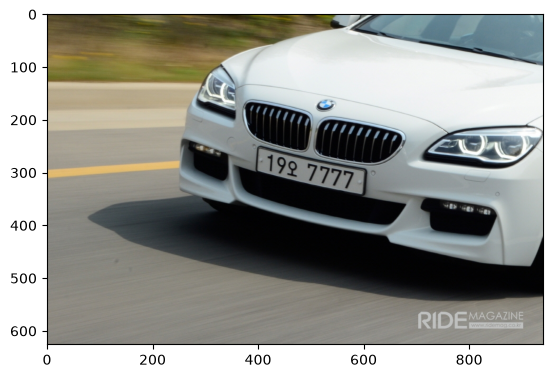

In [3]:
img_ori = cv2.imread(os.path.join(base_path, '1.jpg'))

height, width, channel = img_ori.shape
print(img_ori.shape)   # height, width, channel 

plt_imshow(img_ori)

# GrayScale 영상

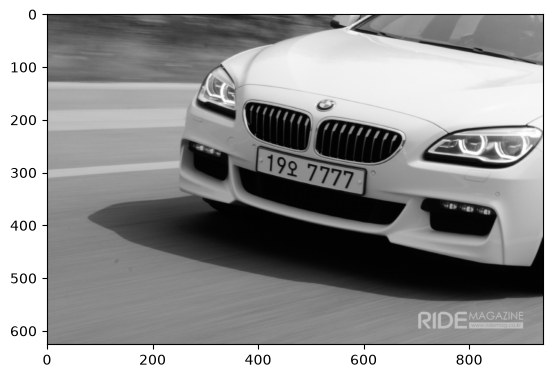

In [4]:
gray = cv2.cvtColor(img_ori, cv2.COLOR_BGR2GRAY)

plt_imshow(gray)

# Gaussian Blur and Adaptive Thresholding 
- 실제 이미지에서 그냥 threshold 하면, 이미지에 노이즈가 많이 생긴다. 
- 그래서 일정량 gaussian blur 를 시킨 다음에 threshold 를 하면 이미지의 노이즈를 어느정도 제거할수 있다.

In [ ]:
# adaptiveThreshold() 함수 참조
# https://opencv-python.readthedocs.io/en/latest/doc/09.imageThresholding/imageThresholding.html
#  기존의 threshold() 함수가 이미지 '전체' 에 적용되기에 이미지에 음영이 다르면 
#  일부 영역이 모두 흰색 또는 검정으로 보여지게 된다
#  이 문제를 보완하기 위해 이미지의 작은 영역별로 thresholding 하는 함수


# cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
# Parameters:
#    src – grayscale image 
#    maxValue – 임계값
#    adaptiveMethod – thresholding value를 결정하는 계산 방법
#    thresholdType – threshold type
#    blockSize – thresholding을 적용할 영역 사이즈
#    C – 평균이나 가중평균에서 차감할 값

# Adaptive Method는 아래와 같습니다.
#    cv2.ADAPTIVE_THRESH_MEAN_C : 주변영역의 평균값으로 결정
#    cv2.ADAPTIVE_THRESH_GAUSSIAN_C :

![](https://opencv-python.readthedocs.io/en/latest/_images/result021.jpg)

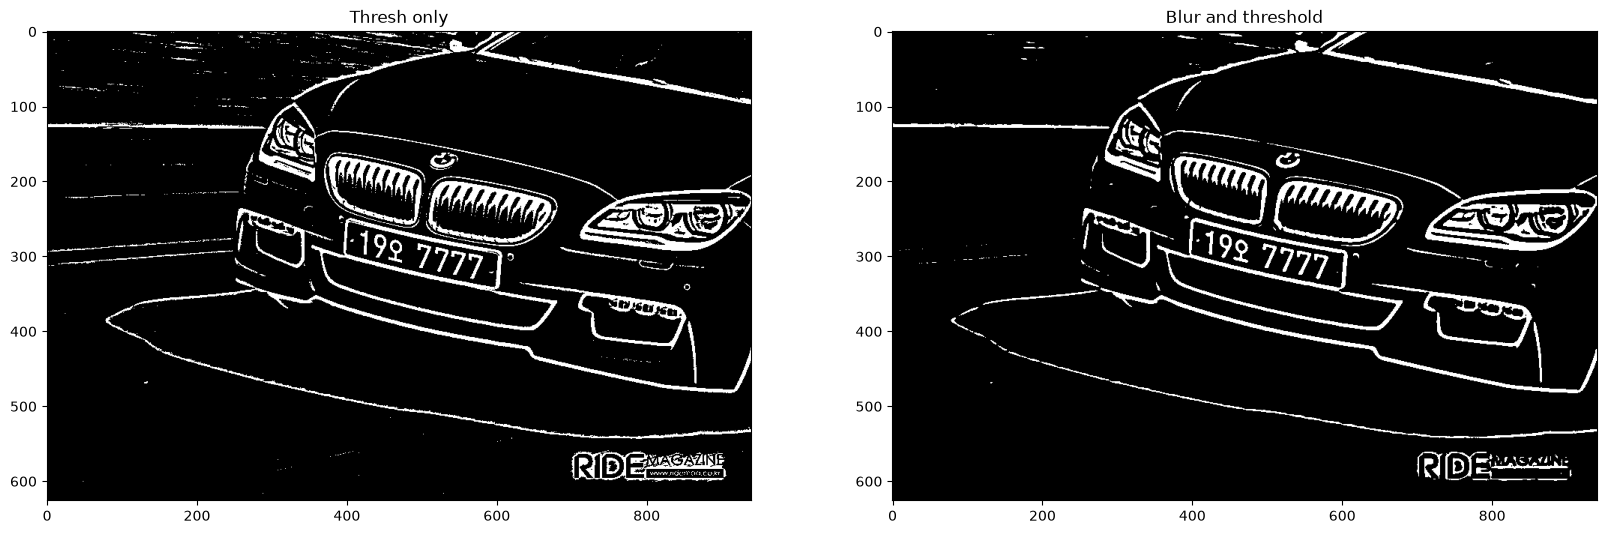

In [10]:
# threshold only
img_thresh = cv2.adaptiveThreshold(
    gray,
    maxValue=255.0,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # thresholding value를 결정하는 계산 방법
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=19,
    C=9,
)

# blur and threshold
img_blurred = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),  # kernel size
    sigmaX=0,  # X방향 sigma
)

img_blur_thresh = cv2.adaptiveThreshold(
    img_blurred,
    maxValue=255.0,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # thresholding value를 결정하는 계산 방법
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=19,
    C=9,
)

# ------------------

fig, axs = plt.subplots(1, 2, figsize=(20, 20))
axs[0].set_title('Thresh only')
axs[0].imshow(img_thresh, cmap='gray')

axs[1].set_title('Blur and threshold')
axs[1].imshow(img_blur_thresh, cmap='gray')

plt.show()

# Find Contours
외각선 (윤곽선) 찾기

In [13]:
contours, _ = cv2.findContours(
    img_blur_thresh,
    mode=cv2.RETR_LIST,
    method=cv2.CHAIN_APPROX_SIMPLE,
)

print(len(contours))  # 검출된 객체의 개수

225


# 윤곽선 그려보기

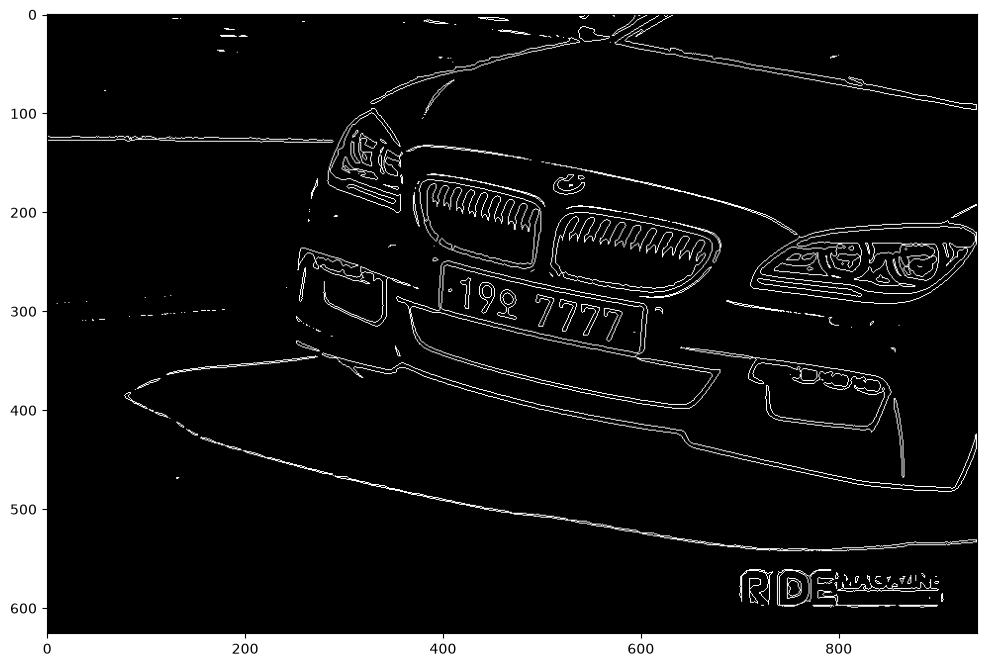

In [15]:
# 검정색 배경 만들고 그 위에 윤곽선 그려보기
temp_result = np.zeros((height, width, channel), dtype=np.uint8)

cv2.drawContours(
    temp_result,
    contours=contours,
    contourIdx=-1,  # cotourIdx 값에 -1을 주면 전체 cotour를 다 그리겠다는 뜻
    color=(255, 255, 255)
)

plt.figure(figsize=(12, 10))
plt_imshow(temp_result)

# Data 수정
- 이제 번호판의 위치를 찾아야 하는데, 찾ㄱ기 쉽도록 우선 데이터를 수정

## boundingRect

In [ ]:
# boundingRect(array)
# https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga103fcbda2f540f3ef1c042d6a9b35ac7

# 사각형 범위 찾기
# 리턴값은 x, y, w, h 

![](https://blog.kakaocdn.net/dn/bBdJe1/btqKwSycvWy/kDH2DnEpLfburD2x0x6cQ0/img.png)

In [16]:
# 첫번째 검출객체
print(contours[0].shape)  # (8, 1, 2)
contours[0]

(8, 1, 2)


array([[[861, 597]],

       [[862, 598]],

       [[882, 598]],

       [[883, 599]],

       [[886, 599]],

       [[887, 598]],

       [[899, 598]],

       [[900, 597]]], dtype=int32)

In [17]:
# 특정 contours의 사각형 범위
cv2.boundingRect(contours[0])

# (x, y, w, h)

(861, 597, 40, 3)

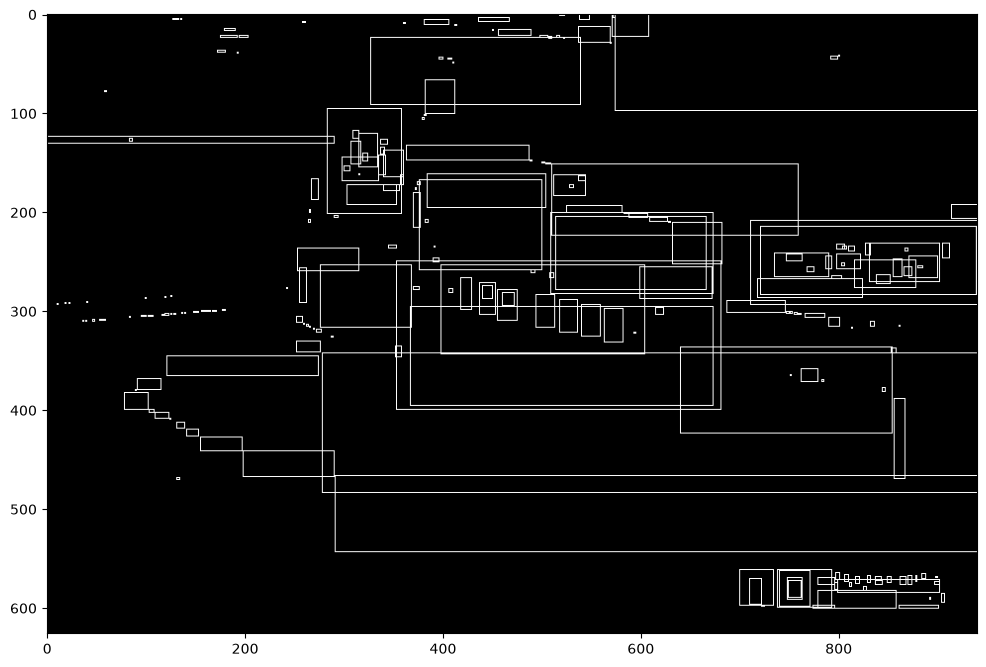

In [19]:
# 검정색 배경에 bounding rect만 그려보기
temp_result = np.zeros((height, width, channel), dtype=np.uint8)

contours_dict = []   # <- 여기다가 contours 들의 정보를 다 저장하겠습니다.

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(temp_result, pt1=(x, y), pt2=(x + w, y + h), color=(255, 255, 255))

    contours_dict.append({
        'contour': contour,
        'x': x,
        'y': y,
        'w': w,
        'h': h,
        'cx': x + (w / 2),  # bounding rect의 중심좌표
        'cy': y + (h / 2)
    })

plt.figure(figsize=(12, 10))
plt_imshow(temp_result)

# Select Candidates by Char Size
- 과연, 이것들 중에 어떤게 번호판인지?
- 이제 위 bounding rect 를 보고 걸러낼것들은 모두 걸러내겠습니다

- 기본 컨셉은 
    - 최소 넓이 지정
    - 숫자의 크기에서 너비-높이 비율로 따져 봅니다



In [20]:
MIN_AREA = 80  # 최소 넓이
MIN_WIDTH, MIN_HEIGHT = 2, 8  # 최소 너비, 높이
MIN_RATIO, MAX_RATIO = 0.25, 1.0  # 너비-높이 비율의 최대/최소

possible_contours = []  # 위 조건에 맞는 것들만 걸러낸 것들을 담아보겠습니다

cnt = 0
for d in contours_dict:  # 위에서 저장했었던 contours_dict 를 순환하면서
    area = d['w'] * d['h']  # 넓이 계산
    ratio = d['w'] / d['h']  # 너비/높이 비율 계산

    # 조건에 맞는 countour 들만 골라서 possible_contours 에 담는다.
    if area > MIN_AREA \
        and d['w'] > MIN_WIDTH and d['h'] > MIN_HEIGHT \
        and MIN_RATIO < ratio < MAX_RATIO:
        d['idx'] = cnt  # 조건에 맞는 각 contour에 idx값을 매겨놓고,
                        # 나중에 조건에 맞는 윤곽선들의 idx만 따로 빼낼겁니다

        cnt += 1
        possible_contours.append(d)

print(len(possible_contours))  # 몇개가 선발되었는지?
possible_contours[0]  # 첫번째만 확인

23


{'contour': array([[[752, 572]],
 
        [[755, 572]],
 
        [[756, 573]],
 
        [[757, 573]],
 
        [[759, 575]],
 
        [[759, 578]],
 
        [[760, 579]],
 
        [[760, 580]],
 
        [[761, 581]],
 
        [[761, 582]],
 
        [[760, 583]],
 
        [[760, 584]],
 
        [[758, 586]],
 
        [[757, 586]],
 
        [[756, 587]],
 
        [[754, 587]],
 
        [[753, 588]],
 
        [[752, 587]],
 
        [[751, 587]],
 
        [[749, 585]],
 
        [[750, 584]],
 
        [[750, 582]],
 
        [[751, 581]],
 
        [[751, 579]],
 
        [[749, 577]],
 
        [[749, 575]]], dtype=int32),
 'x': 749,
 'y': 572,
 'w': 13,
 'h': 17,
 'cx': 755.5,
 'cy': 580.5,
 'idx': 0}

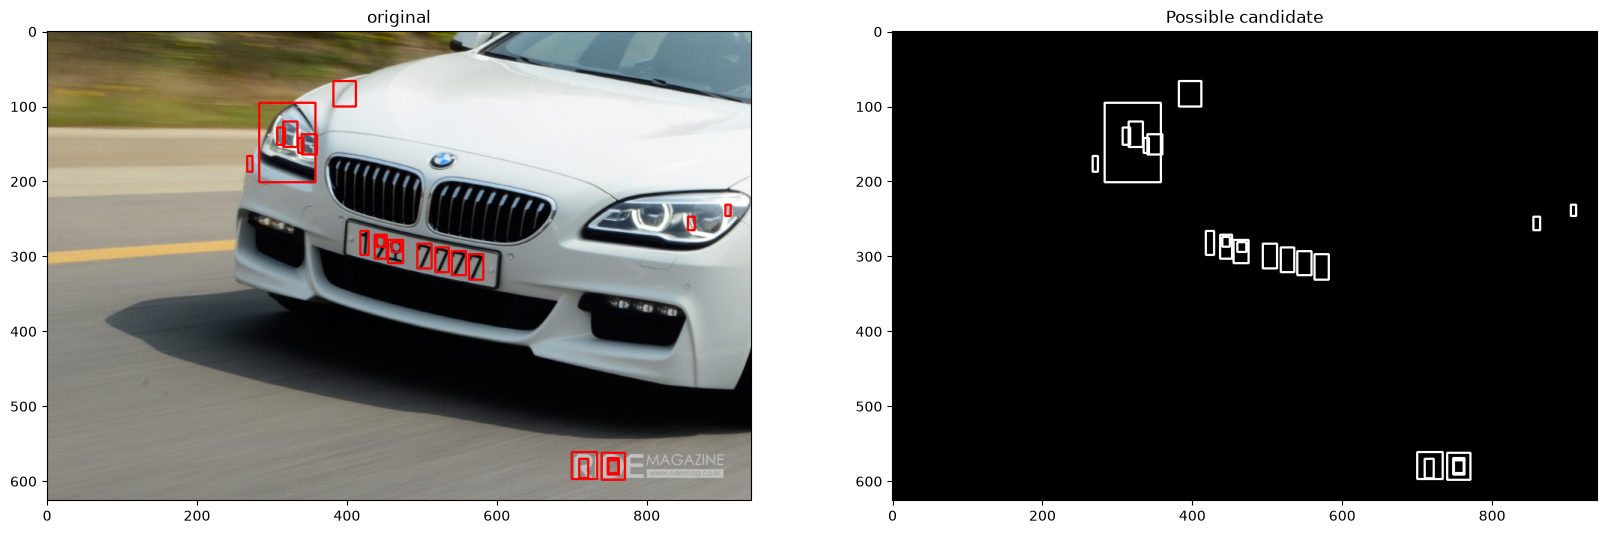

In [23]:
# 이렇게 뽑힘 countour 들 (번호판 숫자 조건에 합한 후보들)을 시각화 해보자
# 원본이미지 위에도 그려보고,  검정색 이미지 위에도 그려보아 비교해보자

temp_result = np.zeros((height, width, channel), dtype=np.uint8)
temp_original = img_ori.copy()

for d in possible_contours:
    cv2.rectangle(temp_result, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(255, 255, 255), thickness=2)
    cv2.rectangle(temp_original, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(0, 0, 255), thickness=2)

fig, axs = plt.subplots(1, 2, figsize=(20, 20))

axs[0].set_title('original')
axs[0].imshow(cv2.cvtColor(temp_original, cv2.COLOR_BGR2RGB))

axs[1].set_title('Possible candidate')
axs[1].imshow(temp_result, cmap='gray')

plt.show()

# 배치에 따른 번호판 후보 추출

In [ ]:
# 이제 이  possible_contours 중에서 '배치 방식'을 보고
# 다시 번호판 후보들을 걸러내보겠습니다.

# 대체로 보면 어느정도 번호들은 일렬로 나열되어 있습니다.  
# 각도나 회전 정도는 있을지언정. 순차적인 형태로 배치 되어 있을겁니다
# 이러한 배열을 보고 가능성이 높은 것들을 추려낼겁니다

In [24]:
# contour 와 contour 사이의 길이 제한
MAX_DIAG_MULTIPLYER = 5

# 측정할 contour 의 대각선 길이를 diagonal length 라 한다면 (파란색)
# 그 중심 (첫번째 contour) 와 후보군으로 여길 countour 랑 의 중심간의 길이가
# 첫번째 countour 의 diagonal length 의 'x 5배' 안에 있어야 한다!  라고 가정/설정 하겠습니다
# 이는 값을 계속 바꾸어 가며 해봐야 한다.

In [25]:
MAX_ANGLE_DIFF = 12.0

# 첫번째 contour 와 두번째 contour 의 중심을 이었을때
# 직각삼각형을 그릴수가 있다 
# 이때 발생되는 각도 θ 의 최대값! 설정
# 즉, rect 의 각도가 너무 벌어져 있으면 이는 번호판 후보군에 들지 않는다! 라고 판단하는 겁니다

In [26]:
MAX_AREA_DIFF = 0.5

# 면적의 차이.  일정비율 이상 차이나면 번호판 후보군으로 인정 안함.

In [27]:
MAX_WIDTH_DIFF = 0.8
MAX_HEIGHT_DIFF = 0.2

# 너비, 높이의 차이.  일정비율 이상 차이나면 번호판 후보군으로 인정 안함.

In [28]:
MIN_N_MATCHED = 3

# 위 조건들을 만족하는 후보군 그룹이 3개 contour객체 미만으로 구성되면 번호판으로 인정 안함

In [29]:
# 다시 확인
print(len(possible_contours))
possible_contours[0]

23


{'contour': array([[[752, 572]],
 
        [[755, 572]],
 
        [[756, 573]],
 
        [[757, 573]],
 
        [[759, 575]],
 
        [[759, 578]],
 
        [[760, 579]],
 
        [[760, 580]],
 
        [[761, 581]],
 
        [[761, 582]],
 
        [[760, 583]],
 
        [[760, 584]],
 
        [[758, 586]],
 
        [[757, 586]],
 
        [[756, 587]],
 
        [[754, 587]],
 
        [[753, 588]],
 
        [[752, 587]],
 
        [[751, 587]],
 
        [[749, 585]],
 
        [[750, 584]],
 
        [[750, 582]],
 
        [[751, 581]],
 
        [[751, 579]],
 
        [[749, 577]],
 
        [[749, 575]]], dtype=int32),
 'x': 749,
 'y': 572,
 'w': 13,
 'h': 17,
 'cx': 755.5,
 'cy': 580.5,
 'idx': 0}

In [38]:
# 번호판 글자 그룹을 찾는 함수 정의
# possible_contours를 매개변수로 넘겨줄거다
def find_chars(contour_list):
    matched_result_idx = []   # 최종적으로 남는 index 값을 담아서 리턴할거다

    # contour_list에서 가용한 모든 contour (d1, d2) 두개의 조합을 비교
    for d1 in contour_list:
        matched_contours_idx = []   # 'd1'과 '조건 통과된 contour(d2들)'을 담을거다

        for d2 in contour_list:
            if d1['idx'] == d2['idx']:   # d1과 d2가 같으면 넘어가구.
                continue

            # 두 contour 사이의 거리를 구하기 위해 dx, dy 계산
            dx = abs(d1['cx'] - d2['cx'])
            dy = abs(d1['cy'] - d2['cy'])
            distance = np.linalg.norm(np.array([d1['cx'], d1['cy']]) - np.array([d2['cx'], d2['cy']]))

            # d1의 대각선 길이
            diagonal_length1 = np.sqrt(d1['w'] ** 2 + d1['h'] ** 2)

            # 각도 구하기             
            if dx == 0:  # dx가 0이면 90도
                angle_diff = 90
            else:
                angle_diff = np.degrees(np.arctan(dy / dx)) # arctan()의 리턴값은 radian 값이다 
                                                            # 이를 호도법으로 변환 np.degrees()

            # 면적 비율, 폭 비율, 높이 비율
            area_diff = abs(d1['w'] * d1['h'] - d2['w'] * d2['h']) / (d1['w'] * d1['h'])
            width_diff = abs(d1['w'] - d2['w']) / d1['w']
            height_diff = abs(d1['h'] - d2['h']) / d1['h']      

            # 초기 설정값에 따른 기분에 맞는 contour만 골라서 
            # matched_contours_idx에 contour의 index 추가
            # 즉 d1과 같은 번호판 후보군 d2(들)을 추가
            if distance < diagonal_length1 * MAX_DIAG_MULTIPLYER \
            and angle_diff < MAX_ANGLE_DIFF and area_diff < MAX_AREA_DIFF \
            and width_diff < MAX_WIDTH_DIFF and height_diff < MAX_HEIGHT_DIFF:
                matched_contours_idx.append(d2['idx'])

        
        # 마지막에는 d1도 넣어준다
        matched_contours_idx.append(d1['idx'])

        # 이와 같이 생성된 그룹에서 MIN_N_MATCHED보다 적은 개수가 담겨 있으면 번호판 탈락!
        if len(matched_contours_idx) < MIN_N_MATCHED:
            continue

        # 위 조건들을 다 통과하면 최종 후보군 matched_result_idx에 인텍스 추가
        matched_result_idx.append(matched_contours_idx)

        # 그런데, 여기서 끝내지 않고,
        # 최종후보군에 들어있지 않은 것 들을 한번 더 비교해볼거다.

        # 일단 matched_contours_idx에 들지 않은 것 들을 unmatched_contour_idx에 넣는다
        # matched_contours_idx는 'd1'과 '조건 통과된 contour(d2 들)'이었다
        unmatched_contour_idx = []
        for d4 in contour_list:
            if d4['idx'] not in matched_contours_idx:
                unmatched_contour_idx.append(d4['idx'])

        unmatched_contour = np.take(contour_list, unmatched_contour_idx)

        # 재귀호출
        recursive_contour_list = find_chars(unmatched_contour)

        for idx in recursive_contour_list:
            matched_result_idx.append(idx)

        break                

    return matched_result_idx

In [39]:
# 결과 확인
result_idx = find_chars(possible_contours)
result_idx

# [[7, 8, 10, 12, 5]]   <- 번호판으로 인식된 contour 들

[[7, 8, 10, 12, 5]]

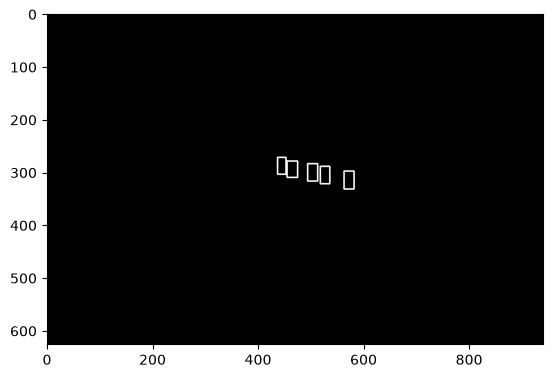

In [42]:
# 시각화로 확인해보기

matched_result = []
for idx_list in result_idx:
    matched_result.append(np.take(possible_contours, idx_list))

temp_result = np.zeros((height, width, channel), dtype=np.uint8)

for r in matched_result:
    for d in r:
        cv2.rectangle(temp_result, pt1=(d['x'], d['y']), pt2=(d['x']+d['w'], d['y']+d['h']), color=(255, 255, 255), thickness=2)

plt_imshow(temp_result)

# Transform Plate Images
affine transform 을 사용하여 이미지를 돌려보자

In [51]:
PLATE_WIDTH_PADDING = 1.3   # 1.3
PLATE_HEIGHT_PADDING = 1.5  # 1.5

MIN_PLATE_RATIO = 3   # 번호판 전체 가로 세로 비율 최소(min)
MAX_PLATE_RATIO = 10  # 번호판 전체 가로 세로 비율 최대(max)

plate_imgs = []
plate_infos = []

for i, matched_chars in enumerate(matched_result):
    # 일단 center X 기준으로 정렬 해준다. (직전까지의 순서는 뒤죽박죽)
    sorted_chars = sorted(matched_chars, key=lambda x: x['cx'])

    # 번호판의 center 좌표를 계산해본다. (첫 contour ~ 마지막 contour의 center 거리)
    plate_cx = (sorted_chars[0]['cx'] + sorted_chars[-1]['cx']) / 2
    plate_cy = (sorted_chars[0]['cy'] + sorted_chars[-1]['cy']) / 2

    # 번호판의 width계산
    plate_width = (sorted_chars[-1]['x'] - sorted_chars[0]['x'] + sorted_chars[-1]['w']) * PLATE_WIDTH_PADDING

    # 번호판의 height계산
    sum_height = 0
    for d in sorted_chars:
        sum_height += d['h']

    plate_height = int((sum_height / len(sorted_chars)) * PLATE_WIDTH_PADDING)

    # 회전 각도 구하기
    triangle_height = sorted_chars[-1]['cy'] - sorted_chars[0]['cy']  # 높이

    triangle_hypotenus = np.linalg.norm(  # 빗변(hypotenus) 구하기
        np.array([sorted_chars[0]['cx'], sorted_chars[0]['cy']]) - 
        np.array([sorted_chars[-1]['cx'], sorted_chars[-1]['cy']])
    )

    # 높이와 빗변을 사용해서 arcsin() 함수로 각도 계산
    angle = np.degrees(np.arcsin(triangle_height / triangle_hypotenus))
    
    print('회전각도', angle)

    # 위 각도가 나오면 회전하는 transformation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center=(plate_cx, plate_cy), angle=angle, scale=1.0)

    # 이를 이미지에 적용하기
    img_rotated = cv2.warpAffine(img_blur_thresh, M=rotation_matrix, dsize=(width, height))

    # plt_imshow(img_rotated)  # 확인용

    # 번호판 부분만 잘라낸다
    img_cropped = cv2.getRectSubPix(
        img_rotated,
        patchSize=(int(plate_width), int(plate_height)),
        center=(int(plate_cx), int(plate_cy)),
    )

    # plt_imshow(img_cropped)  # 확인용

    # 위 결과가 번호판의 가로세로 비율조건에 맞지 않으면 스킵한다
    if img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO \
    or img_cropped.shape[1] / img_cropped.shape[0] > MAX_PLATE_RATIO:
        continue

    plate_imgs.append(img_cropped)
    plate_infos.append({
        'x': int(plate_cx - plate_width / 2),
        'y': int(plate_cy - plate_height / 2),
        'w': int(plate_width),
        'h': int(plate_height)
    })
    

회전각도 11.956584243149132


In [52]:
len(plate_imgs)  # 발견한 번호판들의 개수

1

In [53]:
plate_imgs[0]  # gray scale 값

array([[  0,   0,   0, ...,  66, 191, 255],
       [  0,   0,   0, ..., 105, 225, 255],
       [  0,   0,   0, ..., 124, 246, 255],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [ 79,  42,  57, ...,   0,   0,   0]], shape=(42, 188), dtype=uint8)

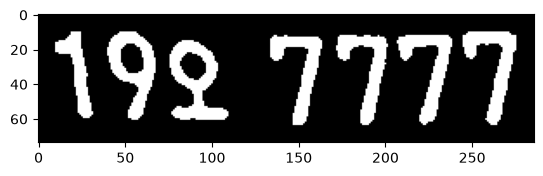

19오 '777'7

19오7777


In [59]:
# 번호판 문자열 인식후 이를 담기 위한 변수들
plate_chars = []  # <- 여기에 번호판의 문자열(들)이 담길거다.
longest_idx, longest_text = -1, 0  # <- 그 중에서 가장 긴 문자열을 번호판이라 할것이다.

for i, plate_img in enumerate(plate_imgs):
    # 1.6 확대
    plate_img = cv2.resize(plate_img, dsize=(0, 0), fx=1.6, fy=1.6)
    
    # threshold 이진화
    _, plate_img = cv2.threshold(
        plate_img, 
        thresh=0.0, 
        maxval=255.0, 
        type=cv2.THRESH_BINARY | cv2.THRESH_OTSU)  # OTSU 사용    

    # plt_imshow(plate_img)  # 확인용

    # 여기서 번호판이 맞는지 확인해보고 글자도 추출할거다
    # 또 한번더 contour를 찾는다
    contours, _ = cv2.findContours(plate_img, mode=cv2.RETR_LIST, method=cv2.CHAIN_APPROX_SIMPLE)

    # 잠시후, 이미지 안에서 추출할 '번호판 부분'의 좌표값을 일단 초기화
    plate_min_x, plate_min_y = plate_img.shape[1], plate_img.shape[0]
    plate_max_x, plate_max_y = 0, 0

    for contour in contours: 
        x, y, w, h = cv2.boundingRect(contour)

        area = w * h  # 면적
        ratio = w / h # 가로세로비율

        # 설정기준에 맞는지 체크해서
        if area > MIN_AREA \
        and w > MIN_WIDTH and h > MIN_HEIGHT \
        and MIN_RATIO < ratio < MAX_RATIO:
            # '번호판 부분' 좌표의 최대, 최소값 구하기
            if x < plate_min_x: plate_min_x = x
            if y < plate_min_y: plate_min_y = y
            if x + w > plate_max_x: plate_max_x = x + w
            if y + h > plate_max_y: plate_max_y = y + h    

    # 위에서 결정된 '번호판 부분' 좌표를 사용하여 '번호판 부분' 만 잘라내기
    img_result = plate_img[plate_min_y:plate_max_y, plate_min_x:plate_max_x]

    # ↓ OCR 글자 인식하기 위해(검출률 향상을 위해) 약간의 처리를 추가합니다
    # 1, 노이즈 제거 (blur + threshold) 하겠습니다
    img_result = cv2.GaussianBlur(img_result, ksize=(3, 3), sigmaX=0) # blur 하고
    
    _, img_result = cv2.threshold(  # threshold도 한번 더 해보고.
        img_result, 
        thresh=0.0, maxval=255.0, 
        type=cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 이미지에 검정색 패딩을 조금 준다 tesseract가 좀 더 인식을 수원하게 하기 위해
    img_result = cv2.copyMakeBorder(
        img_result,
        top=10, bottom=10, left=10, right=10,
        borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0)  # 검정색 패팅
    )

    plt_imshow(img_result)

    # 드디어 OCR 인식!
    # https://github.com/tesseract-ocr/tessdata/blob/main/kor.traineddata
    # C:\Program Files\Tesseract-OCR\tessdata 의 kor.traineddata 을 새로 받아야 한다
    chars = pytesseract.image_to_string(
        img_result,
        lang='kor',
        config='--psm 7 --oem 0',
    )

    print(chars)

    # ■ 이렇게 tesseract 로 읽어낸 문자열 안에 이상한 글자들도 있다. 이들을 걸러내주어야 한다
    # 어짜피 '자동차 번호판' 은 글자 + 숫자로 이루어져 있다.
    # - 반드시 숫자는 있어야 한다.
    result_chars = ''
    has_digit = False
    for c in chars:
        if ord('가') <= ord(c) <= ord('힣') or c.isdigit():
            if c.isdigit():
                has_digit = True
            result_chars += c    

    print(result_chars)

    plate_chars.append(result_chars)

    # 가장 긴 문자열이  우리가 찾는 번호판이라 한다면..
    if has_digit and len(result_chars) > longest_text:
        longest_idx = i


## 최종 결과 출력
- 영상에서 번호판의 위치와 OCR문자 인식으로 검출한 번호판 문자열을 출력!, 파일로도 저장
- 번호판 이름으로 저장시, 한글 파일명 저장 이슈!


In [60]:
# imwrite() 함수 정의
import numpy as np
import cv2
import os
def imwrite(filename, img, params=None):
    try:
        ext = os.path.splitext(filename)[1]
        result, n = cv2.imencode(ext, img, params)

        if result:
            with open(filename, mode='w+b') as f:
                n.tofile(f)
            return True
        else:
            return False
    except Exception as e:
        print(e)
        return False

19오7777


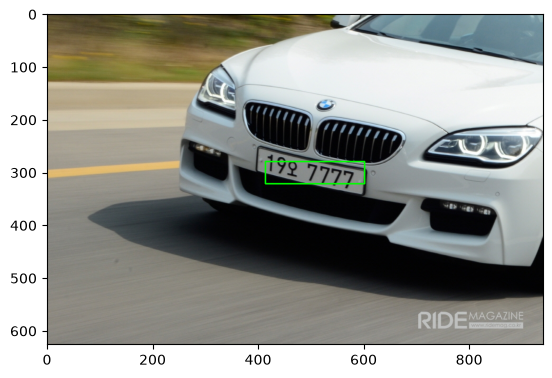

True

In [63]:
info = plate_infos[longest_idx]
chars = plate_chars[longest_idx]

print(chars)

img_out = img_ori.copy()

cv2.rectangle(img_out, pt1=(info['x'], info['y']), pt2=(info['x']+info['w'], info['y']+info['h']), color=(0,255,0), thickness=2)

plt_imshow(img_out)

# 이미지 저장
filename = chars + '.jpg'
imwrite(os.path.join(base_path, filename), img_out)


In [64]:
def car_plate(file_path):
    
    # 원본영상
    img_ori = cv2.imread(file_path)
    # img_ori = cv2.imread(os.path.join(base_path, '1.jpg'))
    
    height, width, channel = img_ori.shape
    
    # gray scals
    gray = cv2.cvtColor(img_ori, cv2.COLOR_BGR2GRAY)
    
    # blur and threshold
    img_blurred = cv2.GaussianBlur(gray, # src 입력영상
                        ksize=(5, 5), # kernel size (0, 0) 을 지정하면 sigma 값에 의해 자동 결정됨
                        sigmaX=0, # x 방향 sigma
                        )
    
    img_blur_thresh = cv2.adaptiveThreshold(
        img_blurred,   
        maxValue=255.0, 
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        thresholdType=cv2.THRESH_BINARY_INV, 
        blockSize=19, 
        C=9
    )
    
    contours, _ = cv2.findContours(
        img_blur_thresh, 
    #     img_thresh, 
        mode=cv2.RETR_LIST, 
        method=cv2.CHAIN_APPROX_SIMPLE
    )
    
    
    contours_dict = []   # <- 여기다가 contours 들의 정보를 다 저장하겠습니다.
    
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        
        # 데이터를 만들고 insert to dict
        contours_dict.append({
            'contour': contour,
            'x': x,
            'y': y,
            'w': w,
            'h': h,
            'cx': x + (w / 2),  # center X
            'cy': y + (h / 2)   # center Y
        })
        
    #------------------------    
    MIN_AREA = 80  # 최소 넓이
    MIN_WIDTH, MIN_HEIGHT = 2, 8  # 최소 너비, 높이
    MIN_RATIO, MAX_RATIO = 0.25, 1.0  # 너비-높이 비율의 최대/최소
    
    possible_contours = []  # 위 조건에 맞는 것들을 걸러낸 것들을 담아보겠습니다
    
    cnt = 0
    for d in contours_dict:  # 위에서 저장했었던 contours_dict 를 순환하면서
        area = d['w'] * d['h']   # 넓이 계산
        ratio = d['w'] / d['h']  # 너비-높이 비율 계산
        
        # 조건에 맞는 것들만 골라서 possible_contours 에 담는다.
        if area > MIN_AREA \
        and d['w'] > MIN_WIDTH and d['h'] > MIN_HEIGHT \
        and MIN_RATIO < ratio < MAX_RATIO:
            d['idx'] = cnt  # 각 contour 의 idx 값을 매겨놓고, 
                            # 나중에 조건에 맞는 윤곽선들의 idx 만 따로 빼낼겁니다
            cnt += 1
            possible_contours.append(d)   
            
    
    #------------------------------------------------------        
    MAX_DIAG_MULTIPLYER = 5 # 5   contour 와 contour 사이의 길이 제한        
    MAX_ANGLE_DIFF = 12.0 # 12.0
    MAX_AREA_DIFF = 0.5 # 0.5
    MAX_WIDTH_DIFF = 0.8
    MAX_HEIGHT_DIFF = 0.2
    MIN_N_MATCHED = 3 # 3
    
    def find_chars(contour_list):
        matched_result_idx = []  # 최종적으로 남는 index 값들 담아서 리턴될 것이다.
        
        # contour_list 에서 2개의 countour (d1, d2) 의 모든 조합을 비교
        for d1 in contour_list:
            matched_contours_idx = []
            for d2 in contour_list:
                if d1['idx'] == d2['idx']:  # d1 과 d2 가 같으면 넘어가구. (비교할 필요 없으니까)
                    continue
    
                # 두 contour 사이의 거리를 구하기 위해 dx, dy 계산 (아래 그림 참조)
                dx = abs(d1['cx'] - d2['cx'])
                dy = abs(d1['cy'] - d2['cy'])
                distance = np.linalg.norm(np.array([d1['cx'], d1['cy']]) - np.array([d2['cx'], d2['cy']]))
                
                # d1 의 대각선 길이
                diagonal_length1 = np.sqrt(d1['w'] ** 2 + d1['h'] ** 2)
    
                # 각도 구하기 (아래 그림 참조)
                if dx == 0:  # dx 가 0 이면 걍 90도
                    angle_diff = 90
                else:
                    angle_diff = np.degrees(np.arctan(dy / dx)) # arctan() 의 리턴값은 radian 값이다 
                                                                # 이를 호도법으로 변환 np.degrees()
                    
                # 면적 비율, 폭 비율, 높이 비율
                area_diff = abs(d1['w'] * d1['h'] - d2['w'] * d2['h']) / (d1['w'] * d1['h'])
                width_diff = abs(d1['w'] - d2['w']) / d1['w']
                height_diff = abs(d1['h'] - d2['h']) / d1['h']
    
                # 초기 설정값에 따른기분에 맞는 contour 만 골라서 
                # matched_contours_idx 에 contour 의 index 추가
                # 즉 d1 과 같은 번호판 후보군 d2(들)을 추가
                if distance < diagonal_length1 * MAX_DIAG_MULTIPLYER \
                and angle_diff < MAX_ANGLE_DIFF and area_diff < MAX_AREA_DIFF \
                and width_diff < MAX_WIDTH_DIFF and height_diff < MAX_HEIGHT_DIFF:
                    matched_contours_idx.append(d2['idx'])
    
            # 마지막에는 d1 도 넣어준다
            # append this contour
            matched_contours_idx.append(d1['idx'])
    
            # 그리하였는데, MIN_N_MATCHED 보다 개수가 적으면 번호판으로 인정안함
            if len(matched_contours_idx) < MIN_N_MATCHED:
                continue
    
            # 위 조건들을 다 통과하면 최종 후보군 matched_result_idx 에 인덱스 추가
            matched_result_idx.append(matched_contours_idx)
    
            # 그런데, 여기서 끝내지 않고, 
            # 최종 후보군에 들이 않은 것들을 한번 더 비교해볼거다
            
            # 일단 matched_contours_idx 에 들지 않은 것들을 unmatched_contour_idx 에 넣고
            unmatched_contour_idx = []
            for d4 in contour_list:
                if d4['idx'] not in matched_contours_idx:
                    unmatched_contour_idx.append(d4['idx'])
    
            # np.take(a, idx)
            # a 에서 idx 와 같은 인덱스의 값만 추출
            
            # possible_contours ?? ▼▼ ?? 이상하다?  전역을 사용한다고?  contour_list
            unmatched_contour = np.take(possible_contours, unmatched_contour_idx)
            
            # 재귀 호출 recursive
            recursive_contour_list = find_chars(unmatched_contour)
            
            for idx in recursive_contour_list:
                matched_result_idx.append(idx)
    
            break
    
        return matched_result_idx  # 최종적으로 남는 index 값들이 담겨져 리턴된다.
    
    
    result_idx = find_chars(possible_contours)
    
    matched_result = []
    for idx_list in result_idx:
        matched_result.append(np.take(possible_contours, idx_list))
        
    PLATE_WIDTH_PADDING = 1.3 # 1.3
    PLATE_HEIGHT_PADDING = 1.5 # 1.5
    
    MIN_PLATE_RATIO = 3  # 번호판 전체 가로세로비 min
    MAX_PLATE_RATIO = 10  # 번호판 전체 가로세로비 max
    
    plate_imgs = []
    plate_infos = []
    
    for i, matched_chars in enumerate(matched_result):
        # 일단 center X 기준으로 정렬 해줍니다 (직전까진 순서가 뒤죽박죽이었을테니)
        sorted_chars = sorted(matched_chars, key=lambda x: x['cx'])
    
        # 번호판의 center 좌표를 계산해봅니다. (처음 contour ~ 마지막 countour 의 center 거리)
        plate_cx = (sorted_chars[0]['cx'] + sorted_chars[-1]['cx']) / 2
        plate_cy = (sorted_chars[0]['cy'] + sorted_chars[-1]['cy']) / 2
        
        # 번호판의 width 계산
        plate_width = (sorted_chars[-1]['x'] + sorted_chars[-1]['w'] - sorted_chars[0]['x']) * PLATE_WIDTH_PADDING
        
        sum_height = 0
        for d in sorted_chars:
            sum_height += d['h']
    
        # 번호판의 height 계산
        plate_height = int(sum_height / len(sorted_chars) * PLATE_HEIGHT_PADDING)
        
        # 현재 번호판이 비뚤어져 있다. 
        # 회전 각도를 함 구해보자.  (아래 그림)
        triangle_height = sorted_chars[-1]['cy'] - sorted_chars[0]['cy']  # 높이
        triangle_hypotenus = np.linalg.norm(  # 빗변 구하기
            np.array([sorted_chars[0]['cx'], sorted_chars[0]['cy']]) - 
            np.array([sorted_chars[-1]['cx'], sorted_chars[-1]['cy']])
        )
        # 높이와 빗변을 사용해서 arcsin() 함수로 각도 계산
        angle = np.degrees(np.arcsin(triangle_height / triangle_hypotenus))
        
        # 위의 각도가 나오면 회전하는 transformation matrix 를 구하고
        rotation_matrix = cv2.getRotationMatrix2D(center=(plate_cx, plate_cy), angle=angle, scale=1.0)
        
        # 이를 이미지에 적용하고
        img_rotated = cv2.warpAffine(
            img_blur_thresh, 
            M=rotation_matrix, 
            dsize=(width, height))
        
        # 잘라낸다.
        img_cropped = cv2.getRectSubPix(
            img_rotated, 
            patchSize=(int(plate_width), int(plate_height)), 
            center=(int(plate_cx), int(plate_cy))
        )
        
        # if img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO or img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO > MAX_PLATE_RATIO:
        if img_cropped.shape[1] / img_cropped.shape[0] < MIN_PLATE_RATIO or img_cropped.shape[1] / img_cropped.shape[0] > MAX_PLATE_RATIO:
            continue
        
        plate_imgs.append(img_cropped)
        plate_infos.append({
            'x': int(plate_cx - plate_width / 2),
            'y': int(plate_cy - plate_height / 2),
            'w': int(plate_width),
            'h': int(plate_height)
        })
    
    #------------------------------------------------    
    # 번호판 문자열 인식후 이를 담기 위한 변수들
    longest_idx, longest_text = -1, 0
    plate_chars = []  # <- 여기에 번호판 문자들이 담길거다.
    
    for i, plate_img in enumerate(plate_imgs):
        plate_img = cv2.resize(plate_img, dsize=(0, 0), fx=1.6, fy=1.6)
        _, plate_img = cv2.threshold(
            plate_img, 
            thresh=0.0, 
            maxval=255.0, 
            type=cv2.THRESH_BINARY | cv2.THRESH_OTSU)  # OTSU 사용
        
        # 또 한번더 contour를 찾는다
        contours, _ = cv2.findContours(plate_img, mode=cv2.RETR_LIST, method=cv2.CHAIN_APPROX_SIMPLE)
        
        # 여기서 번호판이 맞는지 확인해보고 글자도 추출할겁니다    
        # ↓ (위에서 했던것과 거의 동일합니다)
        
        # 이따가 추출할 이미지 안의 번호판 부분의 좌표값 (초기화)
        plate_min_x, plate_min_y = plate_img.shape[1], plate_img.shape[0]
        plate_max_x, plate_max_y = 0, 0
    
        for contour in contours:  # 각 contour 별로
            x, y, w, h = cv2.boundingRect(contour)  # boundingRect 구하고 
            
            area = w * h  # 면적과
            ratio = w / h # 비율 구하고
    
            # 설정기준에 맞는지 체크해서
            if area > MIN_AREA \
            and w > MIN_WIDTH and h > MIN_HEIGHT \
            and MIN_RATIO < ratio < MAX_RATIO:
                # 번호판 의 최대, 최소값 구하기
                if x < plate_min_x:
                    plate_min_x = x
                if y < plate_min_y:
                    plate_min_y = y
                if x + w > plate_max_x:
                    plate_max_x = x + w
                if y + h > plate_max_y:
                    plate_max_y = y + h
        
        
        # 이미지에서 번호판 부분만 잘라내기
        img_result = plate_img[plate_min_y:plate_max_y, plate_min_x:plate_max_x]
        
        # OCR 글씨 인식하기
        # 그전에 약간의 처리를 해서 글씨 인식률을 높여보겠습니다.
        img_result = cv2.GaussianBlur(img_result, ksize=(3, 3), sigmaX=0) # 노이즈 한번 없애도
        
        _, img_result = cv2.threshold(  # threshold 도 한번 더 해보고.
            img_result, 
            thresh=0.0, maxval=255.0, 
            type=cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        
        # 이미지에 패딩을 준다.
        # 검정색 패딩(여백?) 을 주어 tesseract 가 좀더 인식을 수월하게 할수 있도록 한다
        img_result = cv2.copyMakeBorder(
            img_result, 
            top=10, bottom=10, left=10, right=10, 
            borderType=cv2.BORDER_CONSTANT, value=(0,0,0))   # 검정색 패딩(여백?)
    
        chars = pytesseract.image_to_string(
            img_result, 
            lang='kor', 
            config='--psm 7 --oem 0',   # psm 7 은 이미지 안에 글자가 한줄로 놓여져 있다는 가정 조건을 줌.
        )
        
        # ■ 이렇게 tesseract 로 읽어낸 문자열 안에 이상한 글자들도 있다. 이들을 걸러내주어야 한다
        result_chars = ''
        has_digit = False
        for c in chars:
            if ord('가') <= ord(c) <= ord('힣') or c.isdigit():
                if c.isdigit():
                    has_digit = True
                result_chars += c
        
        plate_chars.append(result_chars)
    
        # 가장 문자열이 긴 번호판을 우리가 찾는 번호판이라 하자.
        if has_digit and len(result_chars) > longest_text:
            longest_idx = i
    
    
    # 최종결과        
    info = plate_infos[longest_idx]
    chars = plate_chars[longest_idx]
    
    print(chars)
    
    img_out = img_ori.copy()
    
    cv2.rectangle(img_out, pt1=(info['x'], info['y']), pt2=(info['x']+info['w'], info['y']+info['h']), color=(0, 255,0), thickness=2)
    
    # cv2.imwrite(chars + '.jpg', img_out)  # OpenCV 에서 한글 인코딩 이슈 있다
    filename = chars + '.jpg'
    imwrite(os.path.join(base_path, 'out', filename), img_out)
    
    
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))   

35리6110
49허1769
54가0639
19오7777


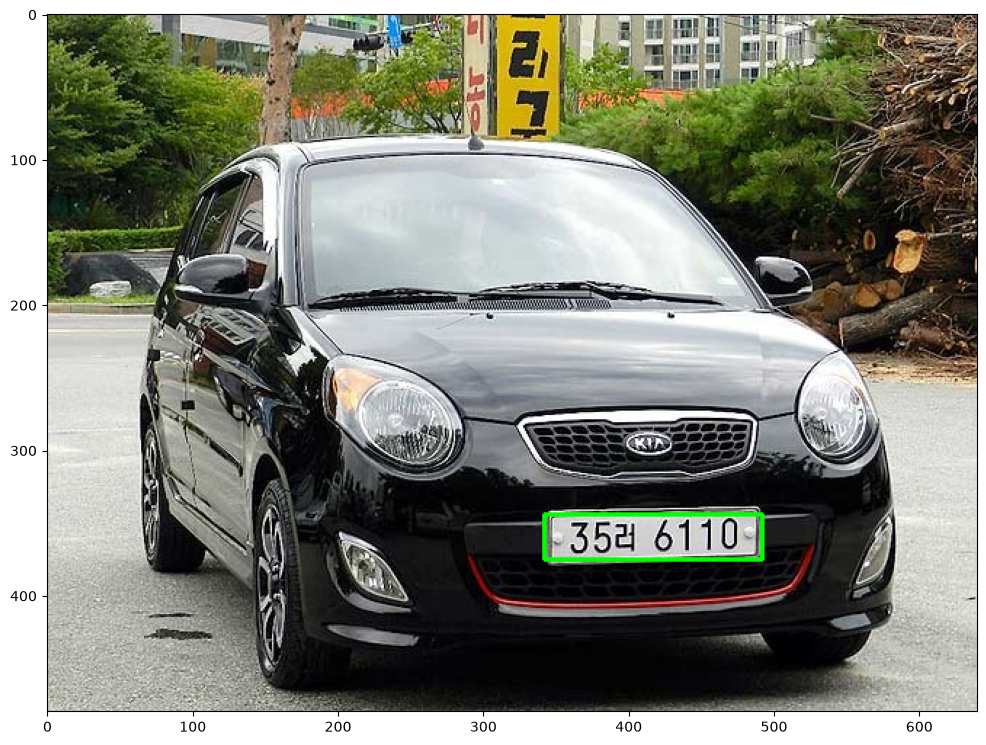

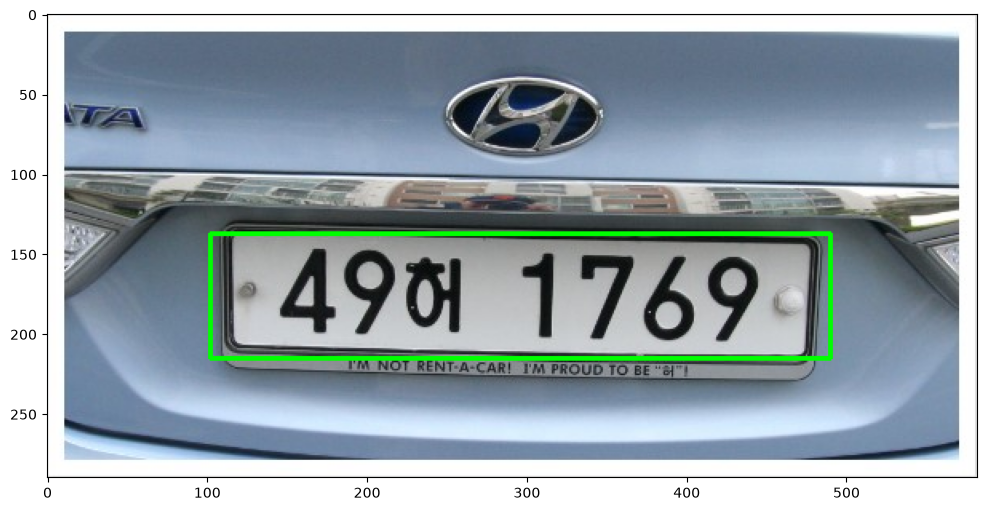

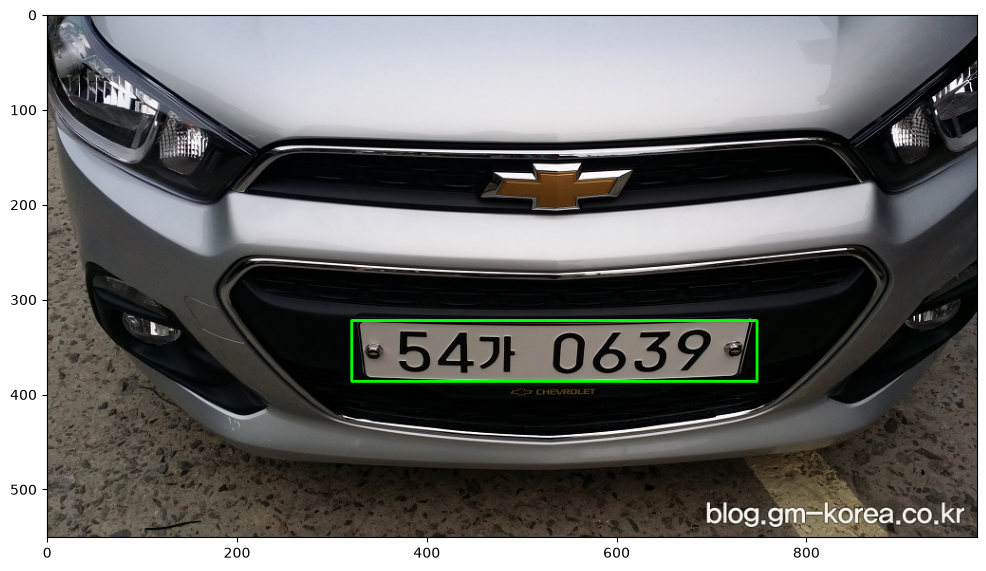

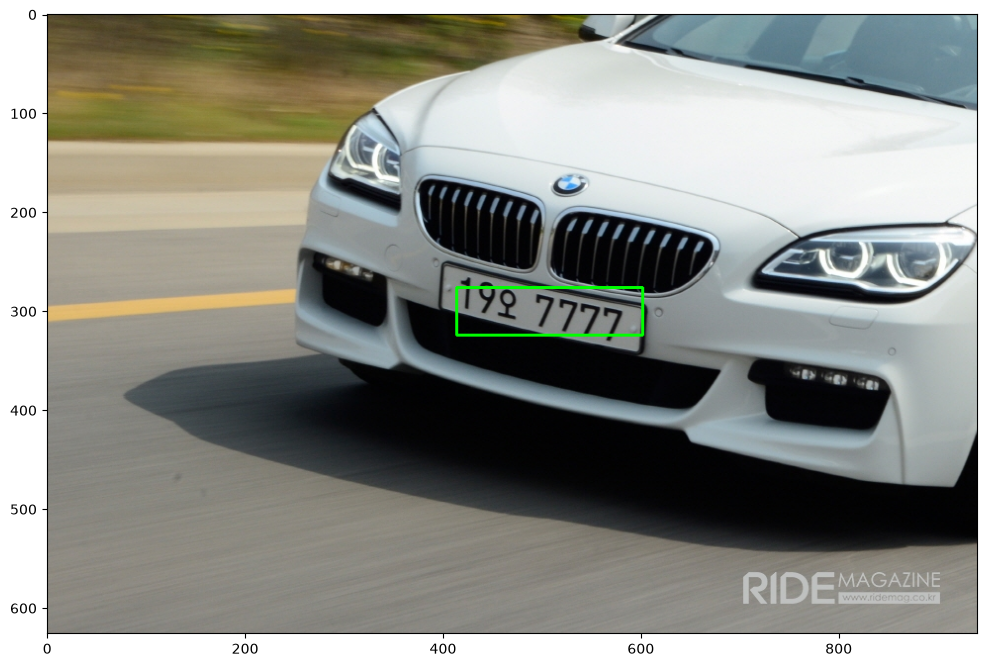

In [67]:
import glob
for file_path in glob.glob(os.path.join(base_path, '*.jpg')):
    car_plate(file_path)